## Clustering gene dynamics 

This script is entirely based on the work done by B. Boumann (bjbouman/time_series_analysis) with small changes to adapt it to our system.

In [1]:
### loading python libraries

# standard libraries
import numpy as np
import pandas as pd

# single cell libraries
import scanpy as sc
sc.settings.verbosity = 0

# plotting libraries
from matplotlib import pyplot as plt

### for timeseries clustering
from tslearn.utils import to_time_series_dataset
from tslearn.clustering import TimeSeriesKMeans
from tslearn.datasets import CachedDatasets
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler
from sklearn.cluster import KMeans

# other
import math #to round up
import warnings
warnings.filterwarnings('ignore') #ignore filter warnings

# own libraries
from plotting import *

In [2]:
### load single-cell dataset
adata_path = "/fast/AG_Pombo/luna/2026_rebuttal/5_kmeans_GEX/260513.DNs.VTA.RNA.seu.sub.data.1387.h5ad"
adata = sc.read_h5ad(adata_path)

In [3]:
### merge control (saline) treatment into one timepoint
control_mask = adata.obs["treatment"] == 'saline'
adata.obs.loc[control_mask, 'timepoint'] = 'control'
adata.obs["timepoint"] = adata.obs["timepoint"].astype('category')

In [4]:
### set order of timepoints
new_order = ['control','h1','h4','h8','h24','d14']
adata.obs["timepoint"] = adata.obs["timepoint"].cat.reorder_categories(new_order)

In [12]:
### make replicate categorical
adata.obs["replicate"] = adata.obs["replicate"].astype('category')

In [13]:
### load degs
degs_path = "/fast/AG_Pombo/luna/2026_rebuttal/5_kmeans_GEX/260513_vta.degs.txt"
degs_df = pd.read_csv(degs_path, sep='\t')
degs = degs_df.iloc[:,0].to_numpy()

In [14]:
### calculate average expression in other timepoints
obs = adata[:,degs].X.toarray()
obs = pd.DataFrame(obs,columns=degs,index=adata.obs["timepoint"])
obs_average = obs.groupby(level=0).mean()

In [15]:
# clean DEG names
degs = degs_df.iloc[:, 0].astype(str).str.strip().tolist()

# keep only genes present in adata
degs_present = [g for g in degs if g in adata.var_names]

# inspect missing genes
missing = [g for g in degs if g not in adata.var_names]

print(f"Present: {len(degs_present)}")
print(f"Missing: {len(missing)}")
print(missing[:20])

Present: 4401
Missing: 0
[]


In [16]:
#25/02/26

# Extract expression matrix and convert it to a DataFrame
obs = pd.DataFrame(adata[:, degs].X.toarray(), columns=degs, index=adata.obs["timepoint"])

# Extract replicate information from adata.obs
replicate_info = adata.obs["replicate"]  # Adjust "replicate" if it has a different column name

# Merge replicate info into the obs DataFrame
obs["replicate"] = replicate_info.values  # Ensure same row order

# Create timepoint_replicate column
obs["timepoint_replicate"] = obs.index.astype(str) + "_" + obs["replicate"].astype(str)

# Compute the average expression for each unique timepoint_replicate group
obs_average_with_reps = obs.groupby("timepoint_replicate").mean()

In [17]:
obs_average
obs_average2 = obs_average

In [18]:
index = ['control', 'h1', 'h4', 'h8', 'h24', 'd14']
# Calculate midpoints and add new rows
midpoints = ['control.h1', 'h1.h4', 'h4.h8', 'h8.h24', 'h24.d14']
for idx, midpoint in enumerate(midpoints):
    timepoints = midpoint.split('.')
    time1, time2 = timepoints[0], timepoints[1]
    
    # Calculate the midpoint values
    midpoint_values = obs_average2.loc[time1] + (obs_average2.loc[time2] - obs_average2.loc[time1]) / 2
    
    # Add new row to the dataframe
    obs_average2.loc[midpoint] = midpoint_values

# Specify the desired order of rows
desired_order = ['control', 'control.h1', 'h1', 'h1.h4', 'h4', 'h4.h8', 'h8', 'h8.h24', 'h24', 'h24.d14', 'd14']

# Reorder rows
obs_average2 = obs_average2.loc[desired_order]

# Display the new dataframe
print(obs_average2)

             Gm28095  Crispld1  6720483E21Rik     Amer3    Lman2l   Gm38115  \
timepoint                                                                     
control     0.029380  0.048758       0.025400  0.019811  0.120770  0.015186   
control.h1  0.016001  0.026707       0.014456  0.033364  0.226336  0.007593   
h1          0.002622  0.004656       0.003511  0.046918  0.331902  0.000000   
h1.h4       0.015346  0.022274       0.012153  0.031850  0.263841  0.010686   
h4          0.028070  0.039893       0.020796  0.016783  0.195781  0.021372   
h4.h8       0.023424  0.035002       0.031683  0.018811  0.216688  0.022954   
h8          0.018779  0.030112       0.042570  0.020838  0.237595  0.024537   
h8.h24      0.015255  0.025095       0.030947  0.029073  0.214729  0.021692   
h24         0.011731  0.020077       0.019323  0.037309  0.191863  0.018848   
h24.d14     0.010481  0.025262       0.026565  0.032916  0.185078  0.020356   
d14         0.009232  0.030446       0.033807  0.028

In [19]:
### scale the average expression
obs_average2 = (obs_average2 - obs_average2.min())/(obs_average2.max() - obs_average2.min())

In [20]:
### create usuable format for time series
formatted_dataset = to_time_series_dataset(obs_average2.T.values.tolist())
formatted_dataset.shape #check that dataset is right size (3D)

(4401, 11, 1)

In [21]:
formatted_dataset_trans = obs_average2.transpose()
scaled_df = formatted_dataset_trans
scaled_df.shape

(4401, 11)

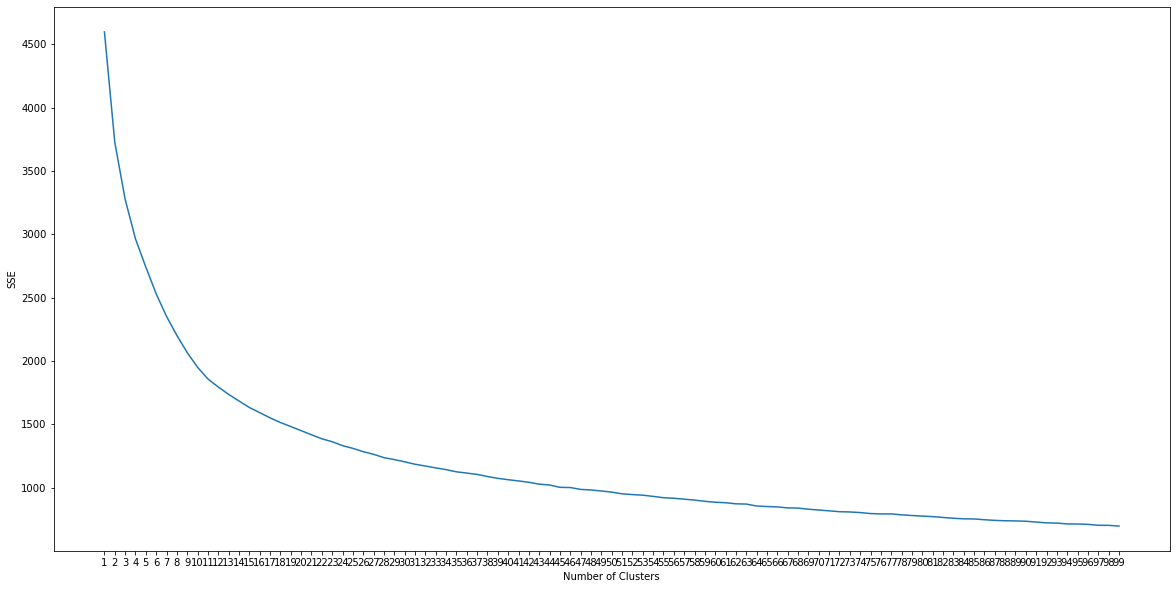

In [23]:
#Elbow:
#initialize kmeans parameters
kmeans_kwargs = {
"init": "random",
"n_init": 15,
"random_state": 1,
}

#create list to hold SSE values for each k
sse = []
for k in range(1, 100):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)
    
plt.figure(figsize=(20, 10))
#visualize results
plt.plot(range(1, 100), sse)
plt.xticks(range(1, 100))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [24]:
### cluster DEGs
seed = 0
np.random.seed(seed)

n_clust = 50 #preselect number of clusters

kmeans = TimeSeriesKMeans(n_clusters=n_clust, max_iter=15, random_state=seed)
y_pred = kmeans.fit_predict(formatted_dataset)

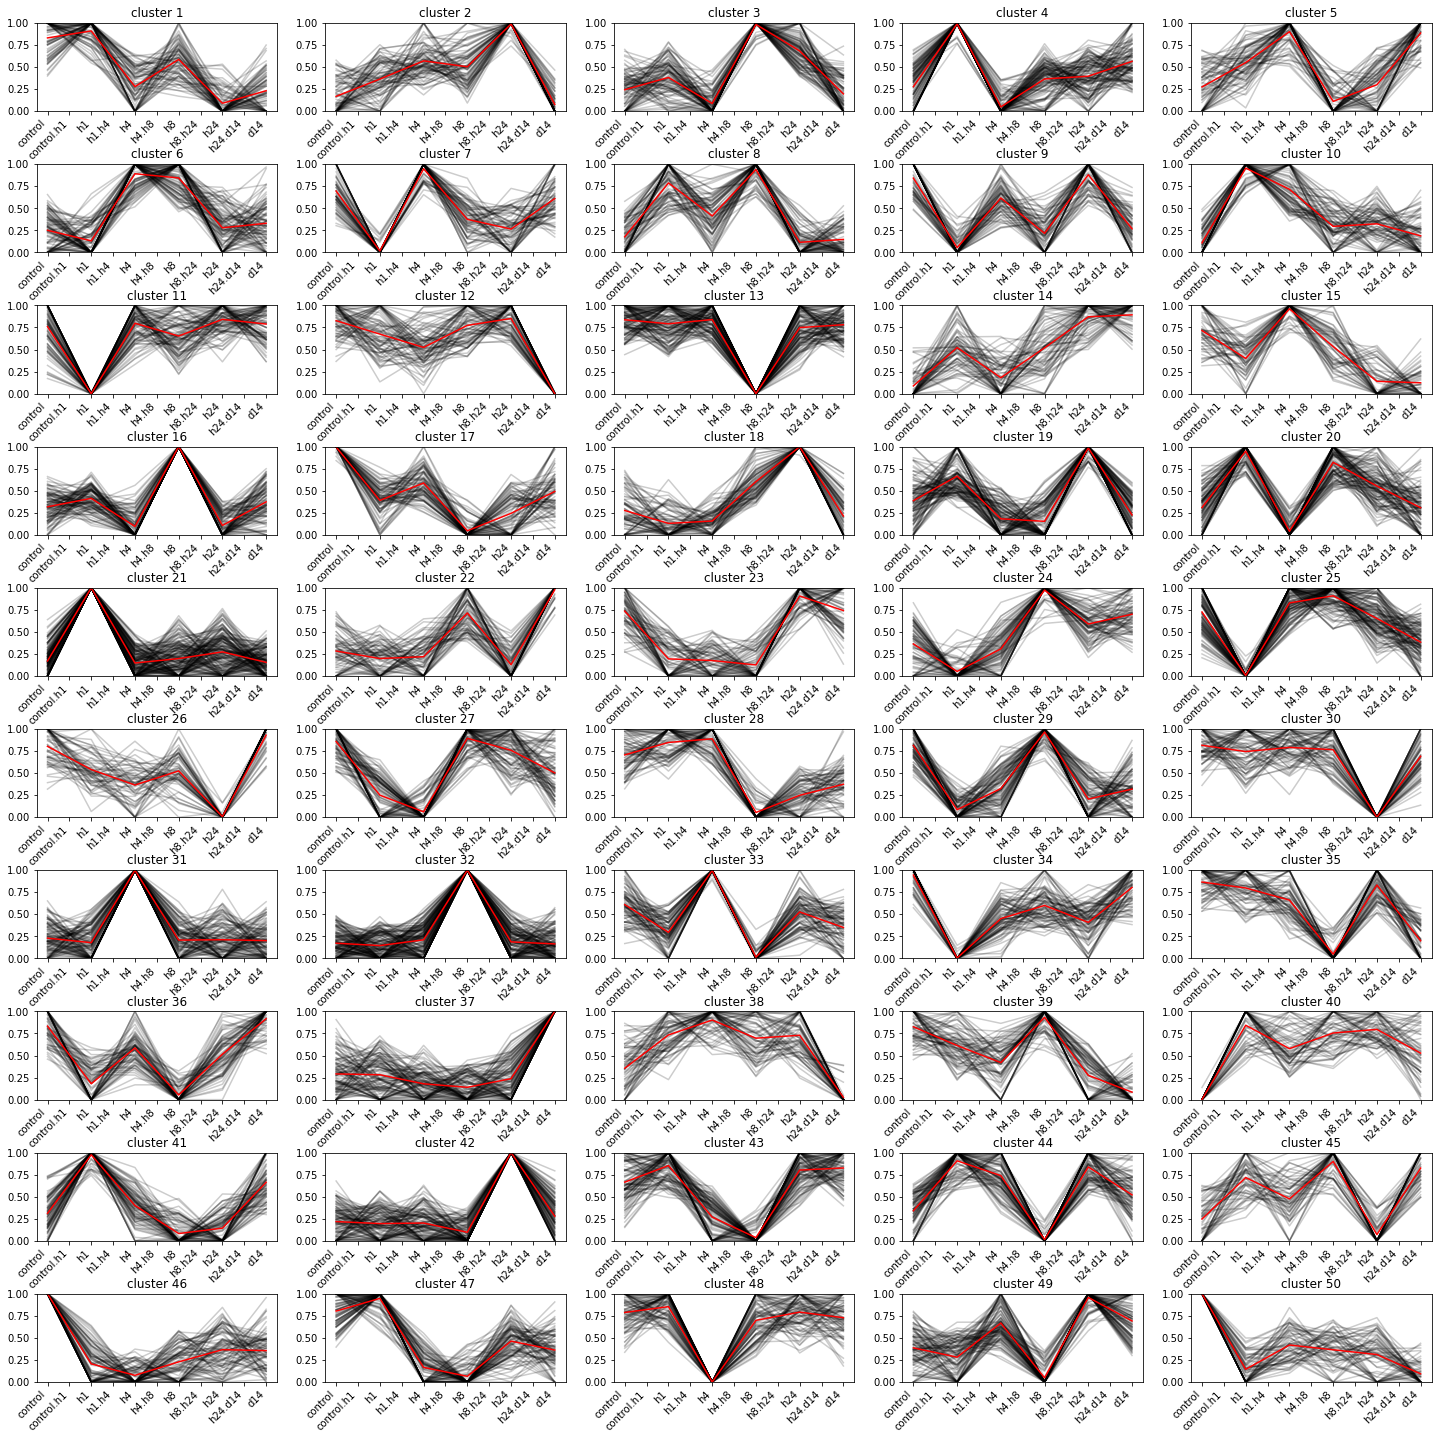

In [25]:
### plot clusters
fig, axs = plt.subplots(math.ceil(n_clust/5), 5,
                            figsize = (25,2.5*math.ceil(n_clust/5)),
                            gridspec_kw={'wspace':0.2, 'hspace':0.6})
axs = axs.ravel()
xticks = np.arange(len(desired_order))

for cluster in range(n_clust):

    for xx in formatted_dataset[y_pred == cluster]:
        axs[cluster].plot(xx.ravel(), "k-", alpha=.2)
    axs[cluster].plot(kmeans.cluster_centers_[cluster].ravel(), "r-")
    axs[cluster].set_ylim([0, 1])
    axs[cluster].set_xticks(xticks)
    axs[cluster].set_xticklabels(desired_order, rotation=45, ha='right')  
    #axs[cluster].set_xlim([0, 11])
    #axs[cluster].set_xticklabels(adata.obs["timepoint"].cat.categories)
    
    axs[cluster].title.set_text('cluster %d' % (cluster + 1))

### save figure
save_path = "/fast/AG_Pombo/luna/2026_rebuttal/5_kmeans_GEX/50clusters.png"
fig.savefig(save_path, bbox_inches='tight', format='png', dpi=300)
    
plt.show()

In [26]:
# Define clusters of interest (change these based on your selection)
clusters_of_interest = [1, 3, 6, 15, 22, 23, 24, 37]  # Example: Change this list to your desired clusters
clusters_of_interest = [c - 1 for c in clusters_of_interest]

xticks = np.arange(len(desired_order))

for cluster in clusters_of_interest:
    fig, ax = plt.subplots(figsize=(5, 2.5))  # Adjust figure size for individual plots

    # Plot all data points in the cluster
    for xx in formatted_dataset[y_pred == cluster]:
        ax.plot(xx.ravel(), "k-", alpha=0.2)

    # Plot cluster centroid
    ax.plot(kmeans.cluster_centers_[cluster].ravel(), "r-")

    # Formatting
    ax.set_ylim([0, 1])
    ax.set_xticks(xticks)
    ax.set_xticklabels(desired_order, rotation=45, ha='right')
    ax.set_title(f'Cluster {cluster + 1}')

    # Save figure
    save_path = f"/fast/AG_Pombo/luna/2026_rebuttal/5_kmeans_GEX/kmeans_cluster_{cluster + 1}.pdf"  # Update with your directory
    fig.savefig(save_path, bbox_inches='tight', format='pdf', dpi=300)
    plt.close(fig)  # Close figure to avoid memory issues

print("Plots saved successfully!")

Plots saved successfully!


In [27]:
### make dictionary with names of genes in each cluster
# convert gene list to numpy array
degs = np.array(degs)

# make dictionary with genes per cluster
dynamic_cluster_dict = {
    f"cluster{cluster+1}": degs[y_pred == cluster]
    for cluster in range(n_clust)
}

# optional: inspect sizes
for k, v in dynamic_cluster_dict.items():
    print(k, len(v))

cluster1 76
cluster2 79
cluster3 96
cluster4 112
cluster5 71
cluster6 95
cluster7 71
cluster8 78
cluster9 73
cluster10 80
cluster11 90
cluster12 78
cluster13 126
cluster14 68
cluster15 57
cluster16 101
cluster17 80
cluster18 77
cluster19 118
cluster20 111
cluster21 171
cluster22 74
cluster23 71
cluster24 82
cluster25 120
cluster26 58
cluster27 87
cluster28 75
cluster29 95
cluster30 72
cluster31 115
cluster32 152
cluster33 88
cluster34 82
cluster35 68
cluster36 72
cluster37 111
cluster38 67
cluster39 73
cluster40 58
cluster41 83
cluster42 118
cluster43 100
cluster44 90
cluster45 57
cluster46 85
cluster47 92
cluster48 84
cluster49 101
cluster50 63


In [28]:
### print genes in cluster of interest
dynamic_cluster_dict['cluster37']

array(['Cdh19', 'Gxylt2', 'Gm20713', 'Galm', 'St18', 'Malrd1', 'Dpp4',
       '2010009K17Rik', 'Stpg2', 'B130024G19Rik', 'Gm10634', 'Lss',
       'Gm47207', 'Hmgcs1', 'Got1l1', 'Hcrtr2', 'Pls1', 'Lrmda', 'Cmss1',
       'A830018L16Rik', 'Gm37107', 'Plxnd1', 'Gm34885', 'Rfx4', 'Gm11715',
       'Prkd1', 'Angpt1', 'Gm50401', 'Cpa6', 'Kcnq5', 'B3gat2', 'Chpf',
       'Gm28609', 'Fam129a', 'Dipk1b', 'Cd302', 'Klhl41', 'Depdc7',
       'Pla2g4b', 'Fahd2a', 'Mkks', 'Chrnb2', 'Gm15886', 'Pla2g12a',
       'Tceanc2', 'Snhg12', 'Pusl1', 'Cdk5', 'Gm17130', 'Gm16226',
       'Golga3', 'Acad12', 'Ap4m1', 'Zfp467', 'Aplf', 'Gm44788',
       'Gm45708', 'Dpy19l1', 'Gm35835', 'Nectin1', 'Rab8b',
       'B230323A14Rik', 'Lars2', 'Traf3ip2', 'Dna2', 'Kcnmb4', 'Tspan31',
       'Galnt10', 'Gosr1', 'Pigs', 'Gm11659', 'Mak', 'Gm3848', 'Gm48099',
       'Cmtm5', 'D130009I18Rik', 'Col14a1', 'Cep97', '4933411O13Rik',
       'Gm15458', 'Adgrf2', 'Yipf3', 'Bysl', 'A930012L18Rik', 'Myo5b',
       'Slc14a2', 'A93

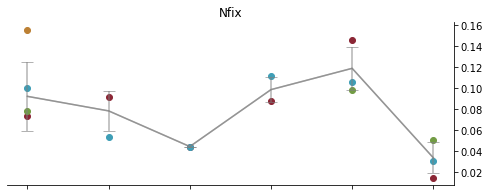

In [138]:
gene_name = "Nfix"
save_directory = "/fast/AG_Pombo/luna/2026_rebuttal/5_kmeans_GEX/gene_dynamics_pdf"
save_path = f"{save_directory}/{gene_name}_expression.pdf"

plot_gene_in_time(adata, gene=gene_name, save=True, save_path=save_path)

In [52]:
# Check current directoy
import os
os.getcwd()

'/fast/AG_Pombo/luna/2026_rebuttal/5_kmeans_GEX'

In [53]:
#Save results as table (convert dictionay into a dataframe): 
dynamic_cluster_df = pd.DataFrame.from_dict(dynamic_cluster_dict, 'index').stack().reset_index(level=0)
dynamic_cluster_df[0] = dynamic_cluster_df[0].str.replace('-', ':', 1)

#Save it:
#dynamic_cluster_df.to_csv('260514_dynamic_cluster_df_version2.csv', index=False)  # Set index=False to exclude the index column